# 04 SHAP Fig3 Fig4

Notebook-first article reproduction. Calculations are kept in notebook cells.

## SHAP Figures 3 and 4
Compute SHAP values from the newly trained model pickles and draw manuscript figures.

In [1]:

from pathlib import Path
import json
import math
import pickle
import shutil
import subprocess
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
MANUSCRIPT_FIGURES = FIGURES / "manuscript"
MODELS_DIR = RESULTS / "models"
SPLITS_DIR = RESULTS / "splits"
MANUSCRIPT = ROOT / "manuscript"
GENERATED = MANUSCRIPT / "generated"

for path in [TABLES, MANUSCRIPT_FIGURES, MODELS_DIR, SPLITS_DIR, GENERATED]:
    path.mkdir(parents=True, exist_ok=True)

TARGET_COL = "-lgLD50, mol/kg"
CLUSTER_COL = "Butina_clusters"
BBB_FILTER_COL = "bbb_rule_pass"
LIGAND_ID_COL = "ligand_id"
FP_PREFIX = "FP_"
RANDOM_STATE = 42

PROTEINS = [
    "1m2z", "1pbq", "1xoq", "2rh1", "2vt4", "2ydo", "2z5x", "3b66", "3kk6", "3ln1",
    "3rze", "4djh", "4ey7", "4iar", "4mqs", "4n6h", "5cxv", "5i71", "5tvn", "5u09",
    "5va1", "6cm4", "6kpf", "6kux", "6lqa", "6pdj", "6x3x", "6y1z", "7f8y", "7kwe",
    "7ljd", "7wc9", "7xnk", "7ym8", "8e9y", "8ef6", "8fhs", "8pjk", "8st0", "8wty",
    "8xvk", "8yn3", "9eo4", "V1A",
]
MODEL_ORDER = ["Baseline", "PCA", "ADME", "Plain", "BBB pass"]

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import Pool
from PIL import Image
from IPython.display import display, Image as IPImage

SHAP_DIR = FIGURES / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)
SHAP_SAMPLE = 200
TARGET_SIZES = {"fig3": (1812, 1412), "fig4a": (2281, 2818), "fig4b": (2281, 2818), "fig4c": (2298, 2818)}
FIG3_MODEL_ORDER = ["Baseline", "Plain", "BBB pass", "ADME"]
FIG3_GROUP_ORDER = ["Fingerprints", "Proteins", "PhysChem", "ADME"]

def save_exact(fig, path: Path, target_size: tuple[int, int], dpi: int = 300) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp.png")
    fig.savefig(tmp, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    with Image.open(tmp) as im:
        im = im.convert("RGB")
        if im.size != target_size:
            im = im.resize(target_size, Image.Resampling.LANCZOS)
        im.save(path, dpi=(dpi, dpi))
    tmp.unlink()

def load_artifact(model_name: str) -> dict:
    with open(MODELS_DIR / f"{model_name}.pkl", "rb") as f:
        return pickle.load(f)

def group_for_feature(col: str) -> str | None:
    if col.startswith(FP_PREFIX):
        return "Fingerprints"
    if col in ["MW, g/mol", "MW", "logP"]:
        return "PhysChem"
    if col in PROTEINS or col.startswith("PC"):
        return "Proteins"
    return "ADME"

def safe_sample(df: pd.DataFrame, n: int) -> pd.DataFrame:
    return df.sample(min(n, len(df)), random_state=RANDOM_STATE)

def load_gene_map() -> dict[str, str]:
    ann_path = DATA / "receptor_panel_annotation.csv"
    if not ann_path.exists():
        return {"V1A": "AVPR1A", "9uwl": "AVPR1A"}
    ann = pd.read_csv(ann_path)
    mapping = {}
    if "panel_col" in ann.columns and "gene" in ann.columns:
        mapping.update(dict(zip(ann["panel_col"].astype(str), ann["gene"].astype(str))))
    if "article_pdb_id" in ann.columns and "gene" in ann.columns:
        mapping.update(dict(zip(ann["article_pdb_id"].astype(str).str.lower(), ann["gene"].astype(str))))
    mapping["9uwl"] = "AVPR1A"
    mapping["V1A"] = "AVPR1A"
    return mapping

def display_columns(cols: list[str], gene_map: dict[str, str]) -> list[str]:
    out = []
    for col in cols:
        if col in gene_map:
            out.append(gene_map[col])
        elif col.lower() in gene_map:
            out.append(gene_map[col.lower()])
        else:
            out.append(col)
    return out


In [2]:

gene_map = load_gene_map()
summary_rows = []
full_feature_rows = []
shap_cache = {}

for model_name in MODEL_ORDER:
    print(f"Computing SHAP for {model_name}")
    art = load_artifact(model_name)
    model = art["model"]
    features = art["features"]
    test_data = art["test_data"]
    X_sample = safe_sample(test_data[features], SHAP_SAMPLE)
    pool = Pool(X_sample, feature_names=features)
    shap_values = model.get_feature_importance(pool, type="ShapValues")
    sv = shap_values[:, :-1]
    shap_cache[model_name] = {"X": X_sample, "values": sv, "base": shap_values[:, -1], "features": features}

    for group in FIG3_GROUP_ORDER:
        idx = [i for i, col in enumerate(features) if group_for_feature(col) == group]
        value = float(np.mean(np.abs(np.sum(sv[:, idx], axis=1)))) if idx else np.nan
        summary_rows.append({"model": model_name, "group": group, "mean_abs_grouped_shap": value, "n_features": len(idx)})

    mean_abs = np.mean(np.abs(sv), axis=0)
    top_order = np.argsort(mean_abs)[::-1][:30]
    for rank, idx in enumerate(top_order, start=1):
        full_feature_rows.append({
            "model": model_name,
            "rank": rank,
            "feature": features[idx],
            "display_feature": display_columns([features[idx]], gene_map)[0],
            "group": group_for_feature(features[idx]),
            "mean_abs_shap": float(mean_abs[idx]),
        })

feature_group_long = pd.DataFrame(summary_rows)
feature_group_wide = feature_group_long.pivot(index="group", columns="model", values="mean_abs_grouped_shap").reindex(index=FIG3_GROUP_ORDER, columns=MODEL_ORDER)
feature_group_wide.to_csv(TABLES / "feature_group_importance_all_models.csv")
feature_group_wide.reindex(index=FIG3_GROUP_ORDER, columns=FIG3_MODEL_ORDER).to_csv(TABLES / "feature_group_importance.csv")
feature_group_long.to_csv(TABLES / "feature_group_importance_long.csv", index=False)
pd.DataFrame(full_feature_rows).to_csv(TABLES / "top_shap_features.csv", index=False)
print(feature_group_wide.to_string())


Computing SHAP for Baseline


Computing SHAP for PCA


Computing SHAP for ADME


Computing SHAP for Plain


Computing SHAP for BBB pass


model         Baseline       PCA      ADME     Plain  BBB pass
group                                                         
Fingerprints  0.261802  0.277484  0.090667  0.262499  0.186370
Proteins      0.079585  0.046524  0.034664       NaN  0.075910
PhysChem      0.207021  0.231096  0.135008  0.236006  0.166972
ADME               NaN       NaN  0.230968       NaN       NaN


Saved results/figures/shap/feature_importance.png size=(1812, 1412)


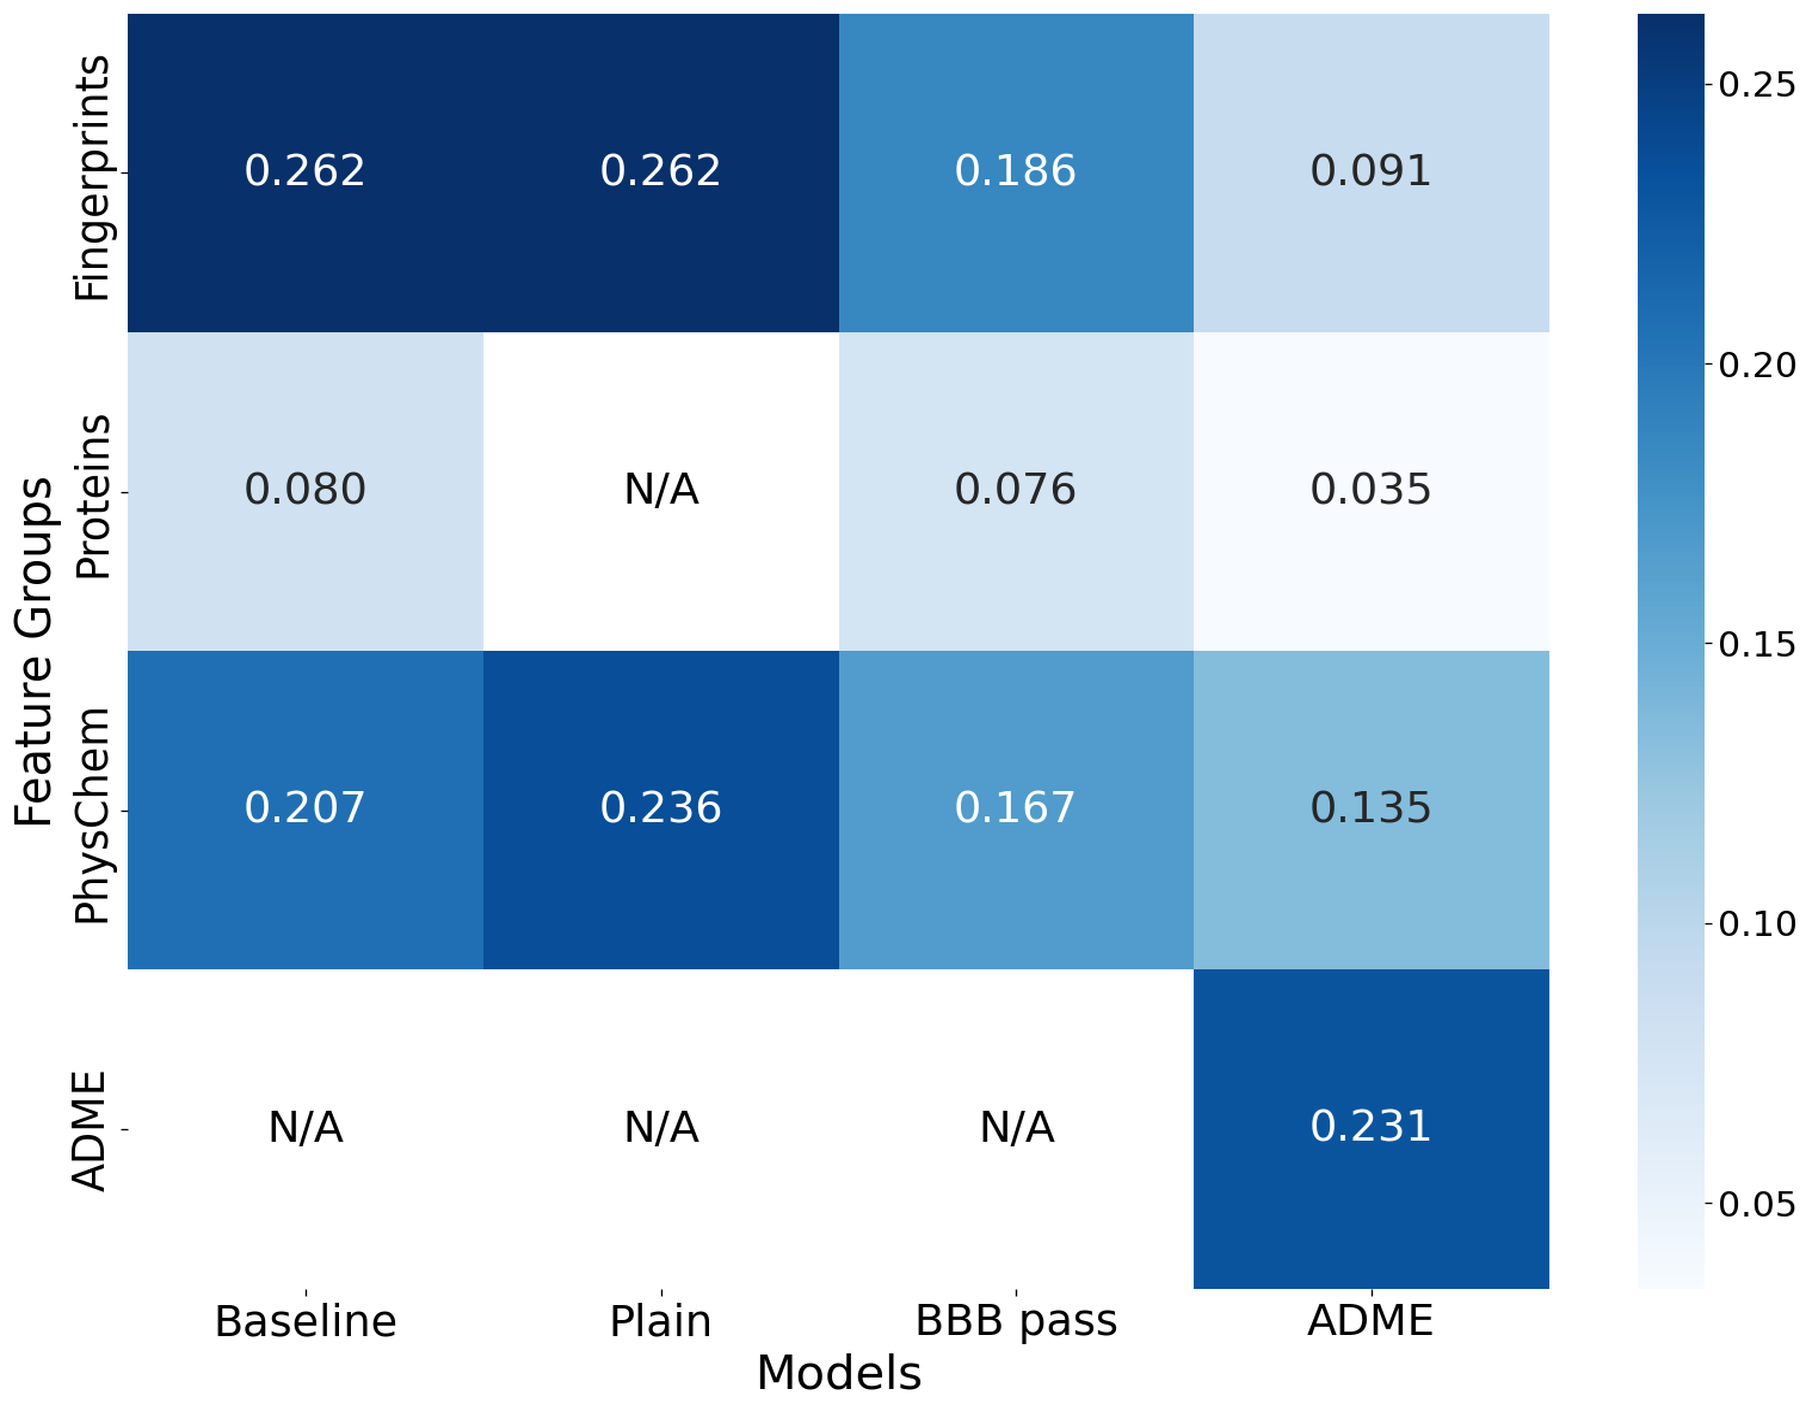

In [3]:

importance = pd.read_csv(TABLES / "feature_group_importance.csv", index_col=0)
importance = importance.reindex(FIG3_GROUP_ORDER)
importance = importance[FIG3_MODEL_ORDER]
fig, ax = plt.subplots(figsize=(16, 12))
cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(
    importance,
    annot=importance.round(3),
    fmt=".3f",
    cmap=cmap,
    mask=importance.isna(),
    cbar=True,
    ax=ax,
    annot_kws={"fontsize": 22},
)
na_y, na_x = np.where(importance.isna().values)
for y, x in zip(na_y, na_x):
    ax.text(x + 0.5, y + 0.5, "N/A", ha="center", va="center", fontsize=22, color="black")
ax.set_xlabel("Models", fontsize=24)
ax.set_ylabel("Feature Groups", fontsize=24)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=22)
ax.set_yticklabels(ax.get_yticklabels(), rotation=90, fontsize=22)
ax.collections[0].colorbar.ax.tick_params(labelsize=18)
fig3 = SHAP_DIR / "feature_importance.png"
save_exact(fig, fig3, TARGET_SIZES["fig3"], dpi=120)
shutil.copy2(fig3, MANUSCRIPT_FIGURES / "fig3.png")
print(f"Saved {fig3.relative_to(ROOT)} size={Image.open(fig3).size}")
display(IPImage(filename=str(fig3)))


Saved results/figures/shap/fig4a.png size=(2281, 2818)


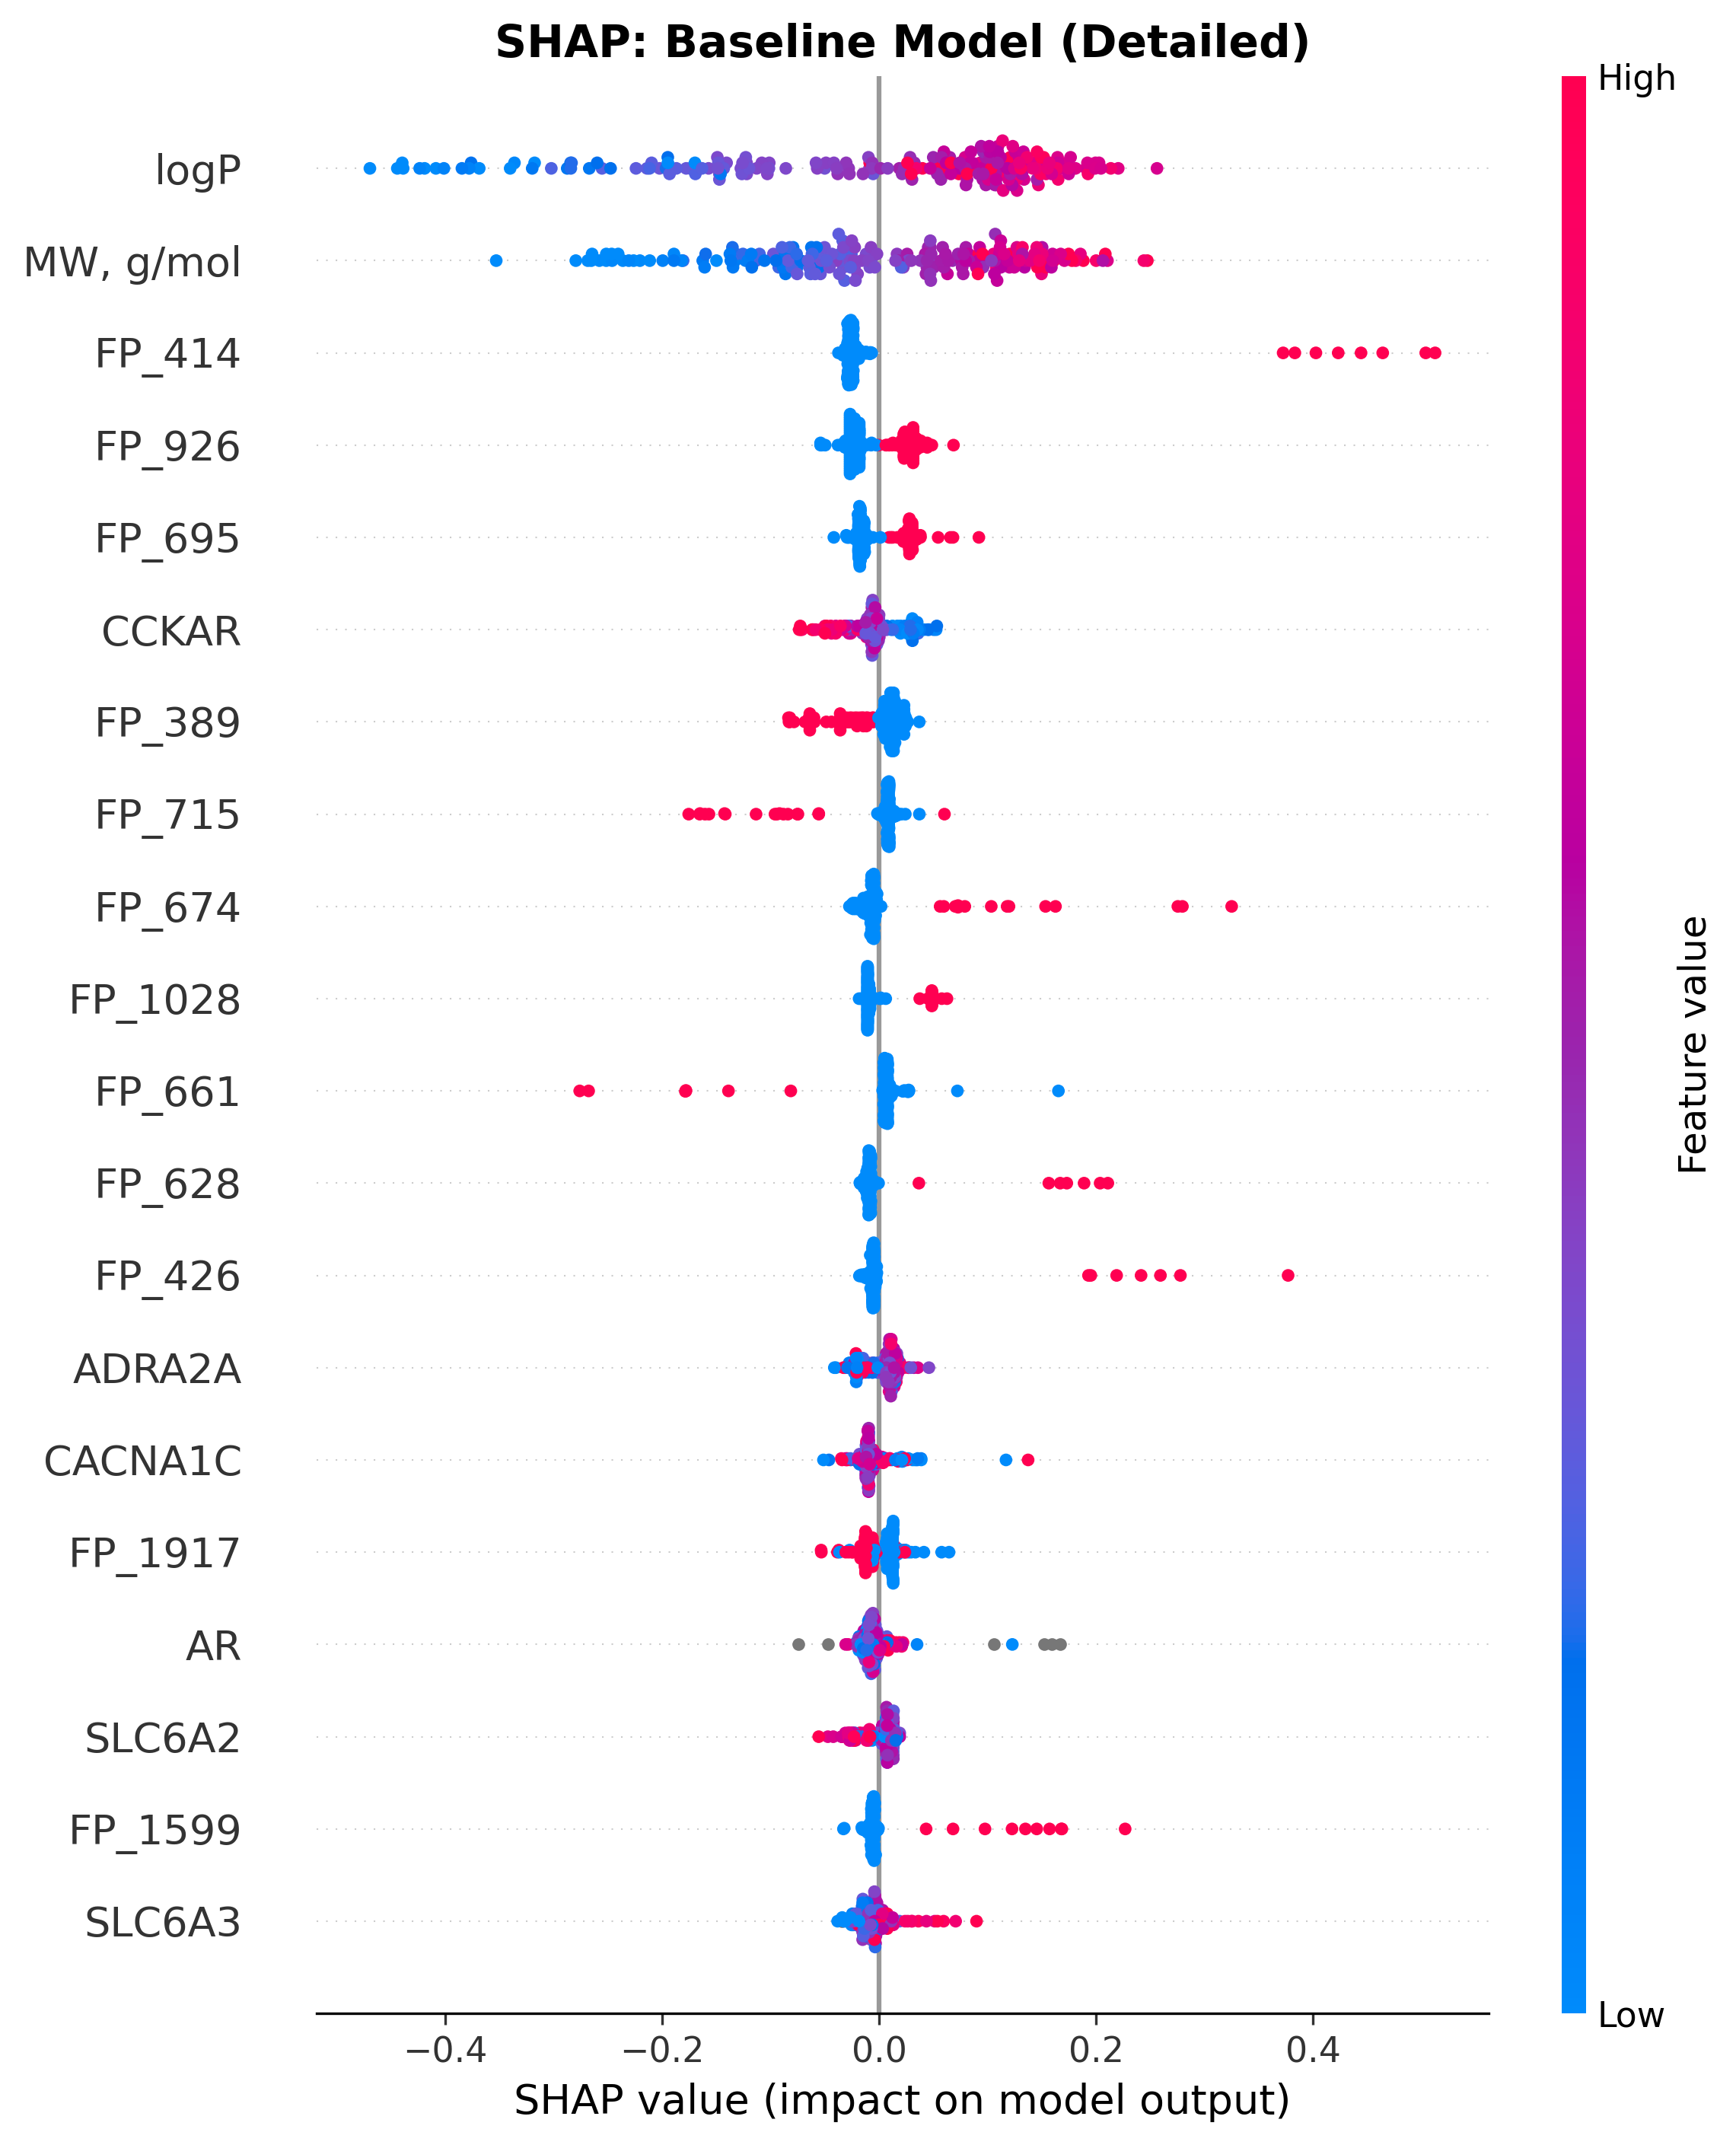

Saved results/figures/shap/fig4b.png size=(2281, 2818)


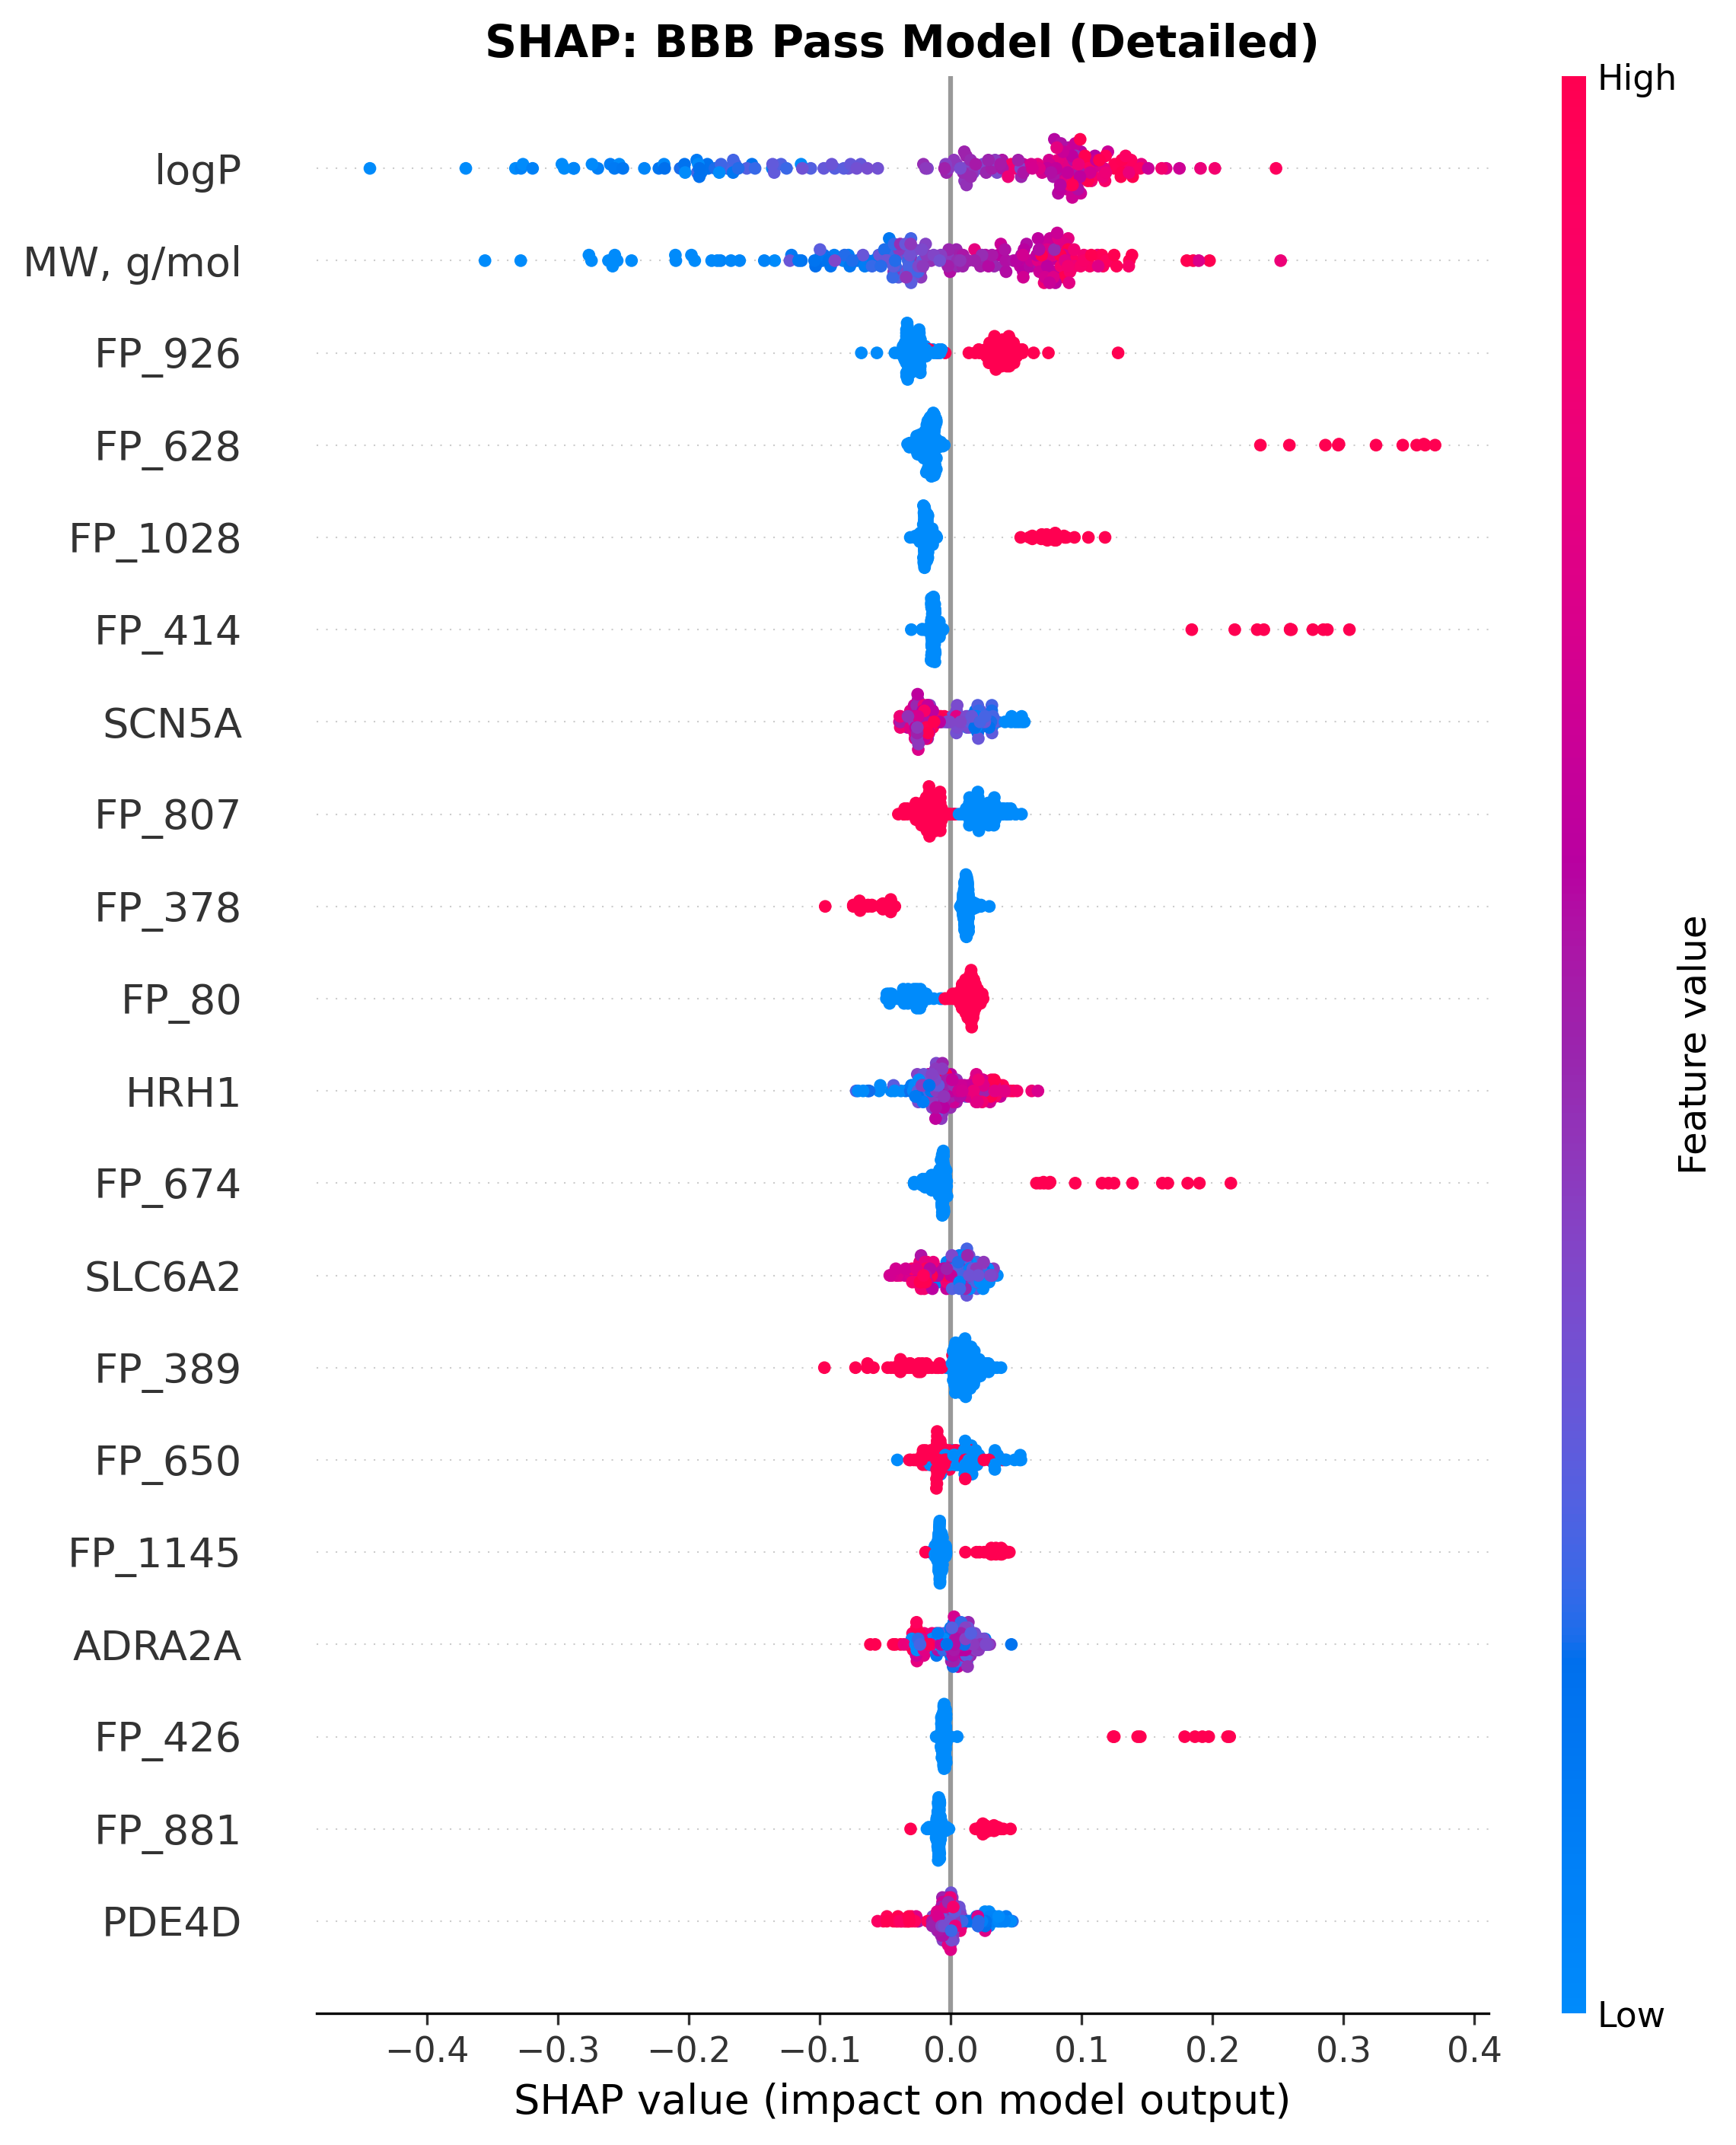

Saved results/figures/shap/fig4c.png size=(2298, 2818)


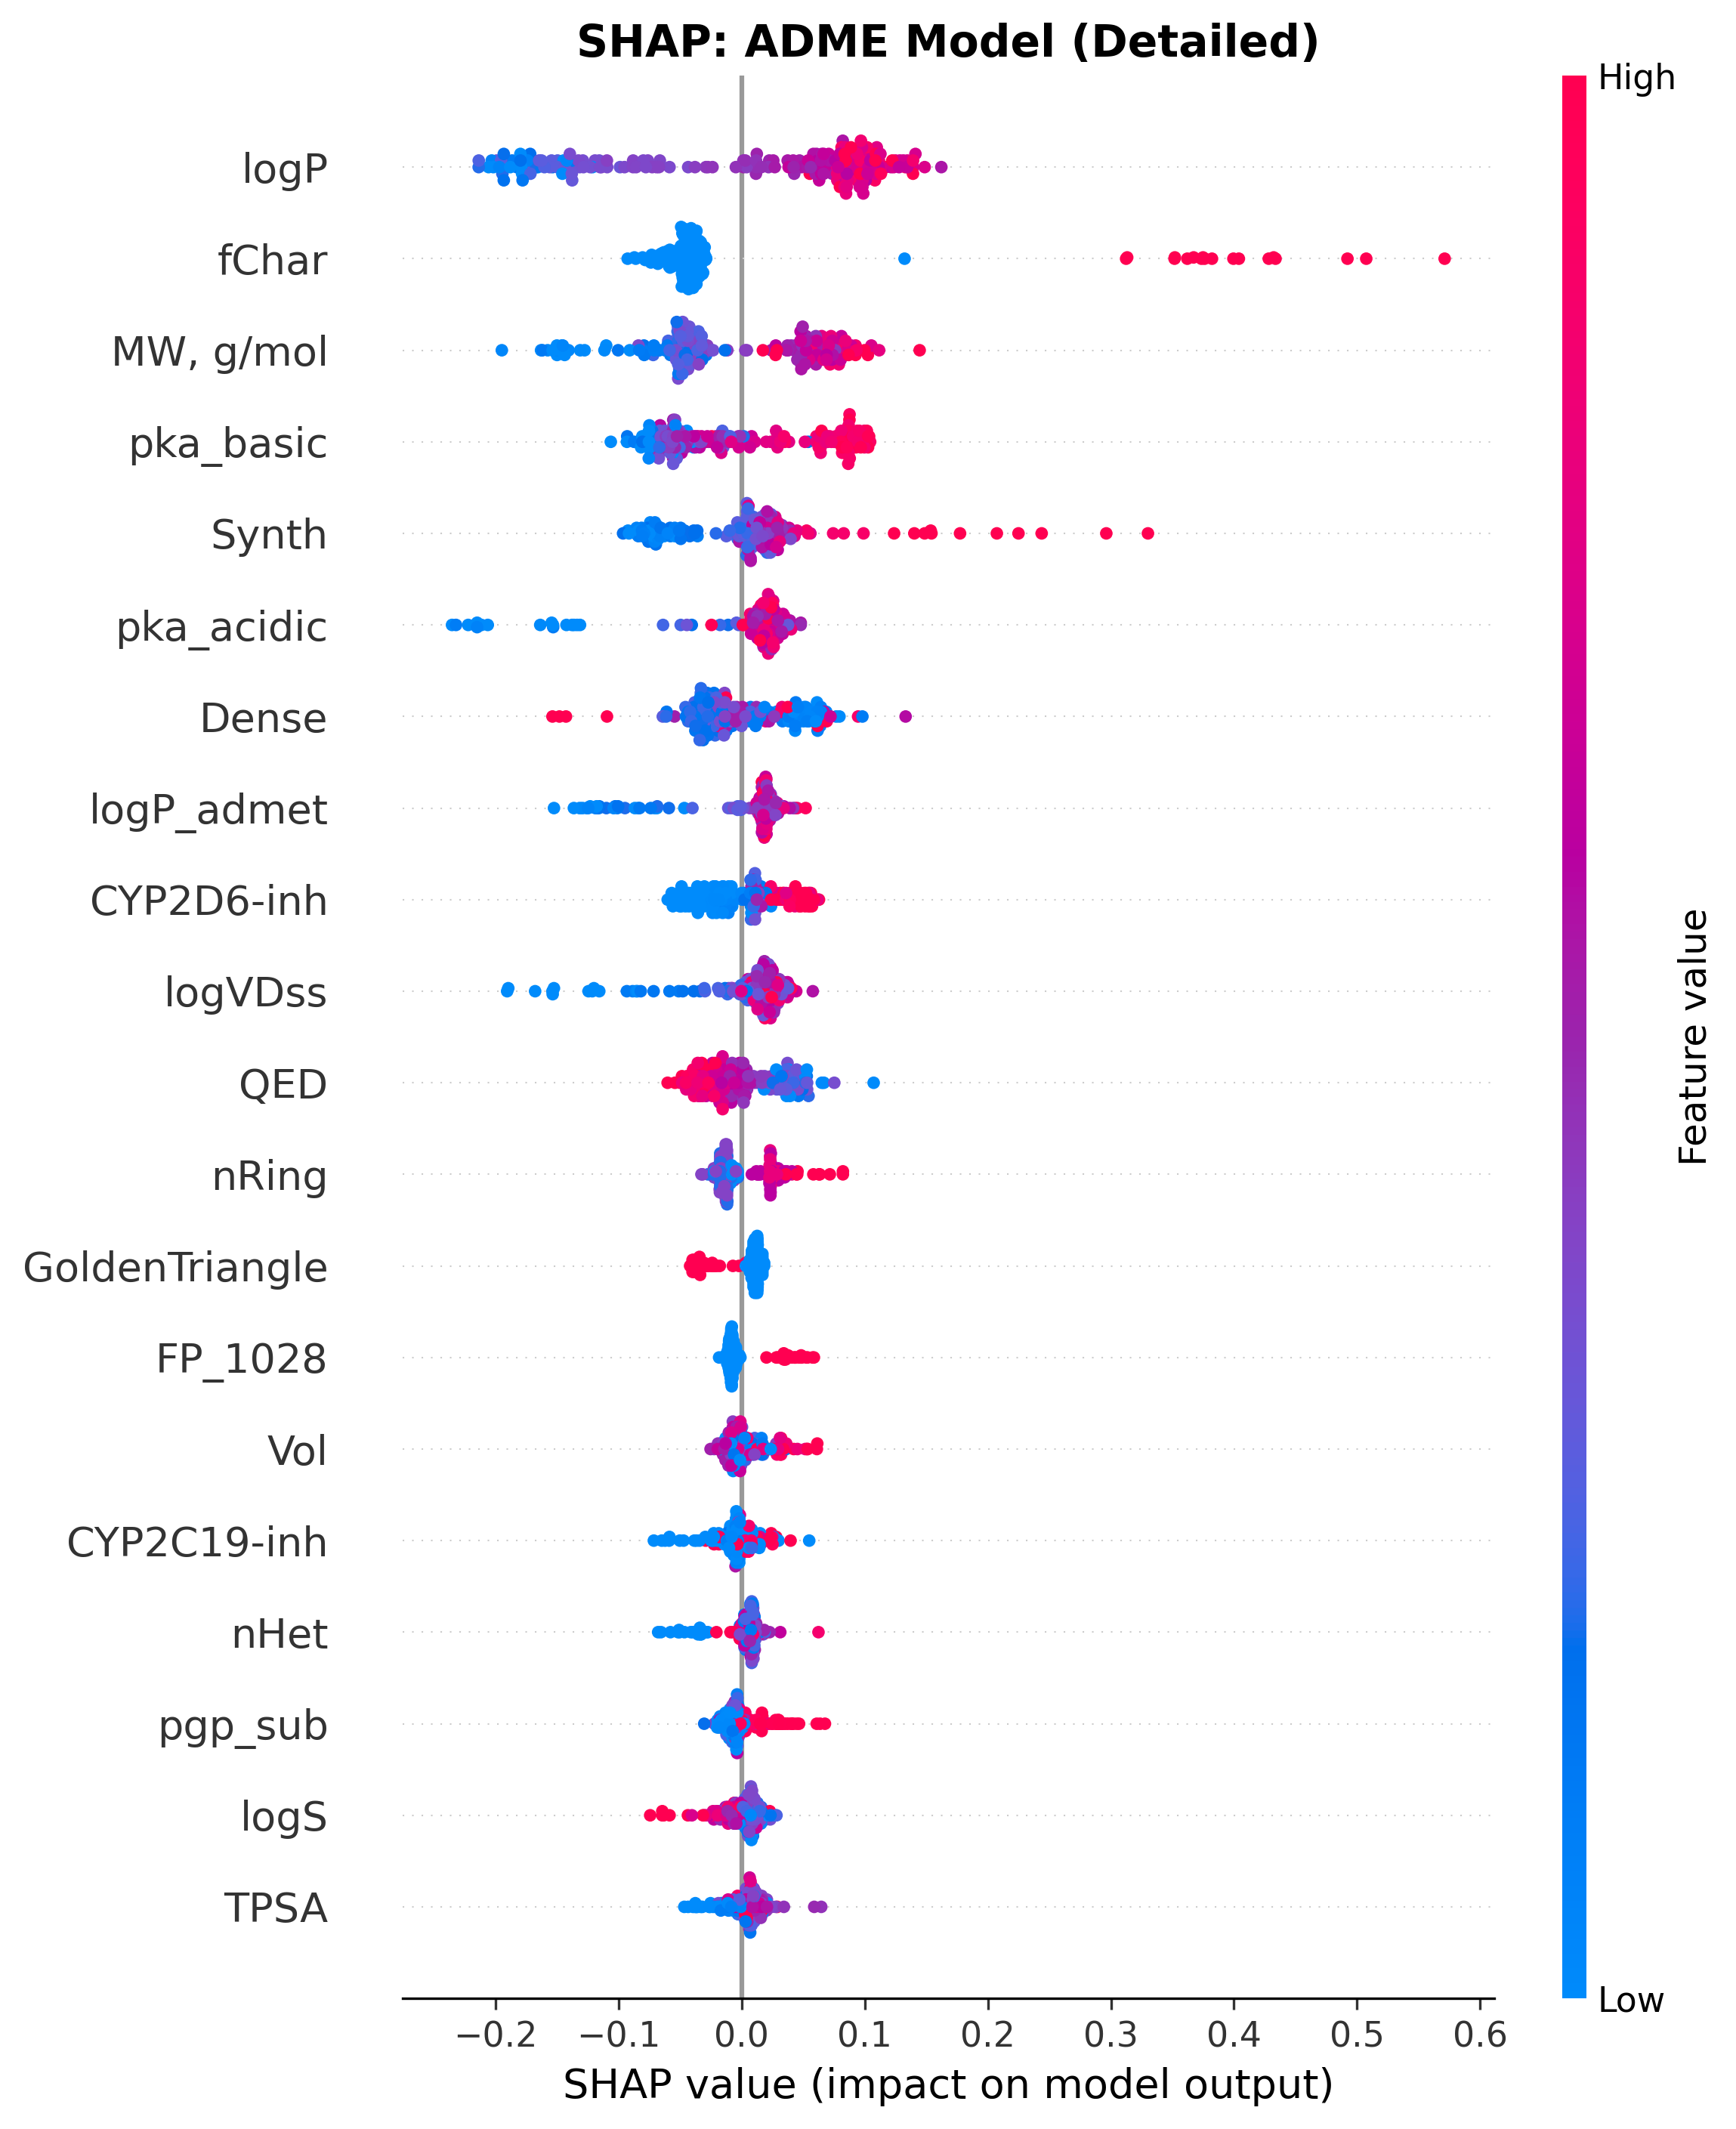

In [4]:

fig4_specs = {
    "Baseline": ("fig4a.png", "Baseline", TARGET_SIZES["fig4a"]),
    "BBB pass": ("fig4b.png", "BBB Pass", TARGET_SIZES["fig4b"]),
    "ADME": ("fig4c.png", "ADME", TARGET_SIZES["fig4c"]),
}
for model_name, (out_name, title_name, target_size) in fig4_specs.items():
    data = shap_cache[model_name]
    X_display = data["X"].copy()
    X_display.columns = display_columns(list(X_display.columns), gene_map)
    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(data["values"], X_display, max_display=20, show=False)
    plt.title(f"SHAP: {title_name} Model (Detailed)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    out = SHAP_DIR / out_name
    save_exact(plt.gcf(), out, target_size, dpi=300)
    shutil.copy2(out, MANUSCRIPT_FIGURES / out_name)
    print(f"Saved {out.relative_to(ROOT)} size={Image.open(out).size}")
    display(IPImage(filename=str(out)))
